In [2]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [3]:
# ─────────────────────────────────────────────
# 모두마켓 데이터 생성 — 이 셀 하나로 오늘 쓸 데이터가 모두 준비됩니다.
# (실제 현장처럼 '텍스트·날짜 오염'을 일부러 심어 둡니다)
# ─────────────────────────────────────────────
np.random.seed(42)

# 1) 고객(customers) -------------------------------------------------
n_customers = 200
last_names = ["김", "이", "박", "최", "정", "강", "조", "윤", "장", "임"]
first_names = ["민준", "서연", "도윤", "지우", "하준", "서윤", "예준", "지유", "주원", "지호"]
names = [np.random.choice(last_names) + np.random.choice(first_names) for _ in range(n_customers)]
# 이름 일부에 앞뒤 공백 오염
for i in np.random.choice(n_customers, 15, replace=False):
    names[i] = "  " + names[i] + " "

# 이메일: 대소문자 + 앞뒤 공백 오염
domains = ["gmail.com", "naver.com", "MODUMARKET.com", "daum.net", "kakao.com"]
emails = []
for i in range(n_customers):
    e = f"user{i+1:03d}@{np.random.choice(domains)}"
    r = np.random.random()
    if r < 0.20:
        e = e.upper()              # 전체 대문자
    elif r < 0.35:
        e = "  " + e + " "         # 앞뒤 공백
    emails.append(e)

# 전화번호: 네 가지 형식 혼재
def make_phone(i):
    mid, end = np.random.randint(1000, 9999), np.random.randint(1000, 9999)
    fmt = i % 4
    if fmt == 0:
        return f"010-{mid}-{end}"
    if fmt == 1:
        return f"010{mid}{end}"
    if fmt == 2:
        return f"010.{mid}.{end}"
    return f"+82 10 {mid} {end}"
phones = [make_phone(i) for i in range(n_customers)]

# 지역: 표기 혼재(공백·영문)
region = np.random.choice(
    ["서울", " 서울 ", "Seoul", "경기", "부산", "인천", "대구"],
    n_customers, p=[0.30, 0.05, 0.05, 0.25, 0.15, 0.10, 0.10])

# 가입일: 네 가지 날짜 포맷 혼재(문자열로 저장)
signup_base = pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0, 365, n_customers), unit="D")
signup = []
for i, d in enumerate(signup_base):
    f = i % 4
    if f == 0:
        signup.append(d.strftime("%Y-%m-%d"))
    elif f == 1:
        signup.append(d.strftime("%Y/%m/%d"))
    elif f == 2:
        signup.append(d.strftime("%Y.%m.%d"))
    else:
        signup.append(d.strftime("%Y%m%d"))

customers = pd.DataFrame({
    "customer_id": [f"C{i+1:04d}" for i in range(n_customers)],
    "name": names,
    "email": emails,
    "phone": phones,
    "region": region,
    "signup_date": signup,
})

# 2) 주문(orders) ----------------------------------------------------
catalog = [("무선 이어폰", "P-1001", 89000), ("블루투스 스피커", "P-1002", 49000),
           ("노트북 거치대", "P-1003", 29000), ("기계식 키보드", "P-1004", 119000),
           ("USB-C 충전기", "P-1005", 19000), ("보조배터리", "P-1006", 39000),
           ("스마트워치", "P-1007", 159000), ("액션캠", "P-1008", 229000)]
n_orders = 2000
pick = np.random.randint(0, len(catalog), n_orders)

product_name, amount = [], []
for j in pick:
    name, codeid, price = catalog[j]
    label = f"{name} ({codeid})"
    r = np.random.random()
    if r < 0.18:
        label = "  " + label + "  "        # 앞뒤 공백
    elif r < 0.30:
        label = label.replace(" ", "  ")    # 단어 사이 이중 공백
    product_name.append(label)
    amount.append(price * np.random.choice([1, 1, 1, 2, 3]))

coupon = np.random.choice(
    ["SALE2025", "WELCOME10", "VIP-2025", "summer25", "FREESHIP", ""],
    n_orders, p=[0.18, 0.15, 0.10, 0.10, 0.07, 0.40])

channel = np.random.choice(["web", "app", "app ", "APP"], n_orders, p=[0.45, 0.45, 0.05, 0.05])

# 주문 일시: 두 가지 포맷 혼재 + 소수의 오류값
dt_base = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 90 * 24 * 3600, n_orders), unit="s")
order_datetime = []
for i, d in enumerate(dt_base):
    if i % 2 == 0:
        order_datetime.append(d.strftime("%Y-%m-%d %H:%M:%S"))
    else:
        order_datetime.append(d.strftime("%Y/%m/%d %H:%M:%S"))
# 오류값 심기: 파싱 불가능한 문자열 12건
for i in np.random.choice(n_orders, 12, replace=False):
    order_datetime[i] = np.random.choice(["처리중", "-", "unknown"])

orders = pd.DataFrame({
    "order_id": [f"O{i+1:05d}" for i in range(n_orders)],
    "customer_id": np.random.choice(customers["customer_id"], n_orders),
    "product_name": product_name,
    "amount": amount,
    "coupon": coupon,
    "channel": channel,
    "order_datetime": order_datetime,
})

print("모두마켓 데이터 생성 완료")
print("customers:", customers.shape, "| orders:", orders.shape)

모두마켓 데이터 생성 완료
customers: (200, 6) | orders: (2000, 7)


In [4]:
# 데이터가 어떻게 '오염'되어 있는지 맨 위 몇 줄을 직접 봅니다.
print("=== customers (고객) ===")
display(customers.head())
print("\n=== orders (주문) ===")
display(orders.head())

=== customers (고객) ===


,customer_id,name,email,phone,region,signup_date
0,C0001,조지우,user001@daum.net,010-8973-9577,경기,2024-04-27
1,C0002,윤하준,user002@gmail.com,01090709666,서울,2024/09/26
2,C0003,조지호,USER003@NAVER.COM,010.9609.7490,서울,2024.03.20
3,C0004,박예준,USER004@KAKAO.COM,+82 10 4600 7783,인천,20240402
4,C0005,윤하준,USER005@KAKAO.COM,010-5971-2205,대구,2024-09-22



=== orders (주문) ===


,order_id,customer_id,product_name,amount,coupon,channel,order_datetime
0,O00001,C0131,무선 이어폰 (P-1001),89000,FREESHIP,app,2025-01-01 23:12:56
1,O00002,C0094,USB-C 충전기 (P-1005),57000,WELCOME10,web,2025/01/25 12:15:09
2,O00003,C0008,기계식 키보드 (P-1004),357000,,web,2025-01-31 14:14:25
3,O00004,C0086,블루투스 스피커 (P-1002),147000,,app,2025/03/30 02:12:54
4,O00005,C0089,무선 이어폰 (P-1001),89000,,web,2025-02-18 23:06:24


In [5]:
# 예제: 정제 전 — region을 그냥 세면 같은 서울이 쪼개진다
print("[정제 전] region 값의 종류")
print(customers["region"].value_counts())
# repr로 보면 숨은 공백이 보입니다.
print("\n숨은 공백 확인:", [repr(x) for x in customers["region"].unique()])

[정제 전] region 값의 종류
region
경기       61
서울       52
부산       32
인천       19
대구       18
Seoul    10
 서울       8
Name: count, dtype: int64

숨은 공백 확인: ["'경기'", "'서울'", "'인천'", "'대구'", "'부산'", "'Seoul'", "' 서울 '"]


In [6]:
# 예제: strip → lower → replace 3단계로 region 통일하기
clean_region = (
    customers["region"]
    .str.strip()                      # 1) 앞뒤 공백 제거
    .str.replace("Seoul", "서울")      # 2) 영문 표기를 한글로 치환
)
customers["region_clean"] = clean_region

print("[정제 후] region_clean 값의 종류")
print(customers["region_clean"].value_counts())

[정제 후] region_clean 값의 종류
region_clean
서울    70
경기    61
부산    32
인천    19
대구    18
Name: count, dtype: int64


In [7]:
# 예제: 이메일 정제 — 앞뒤 공백 제거 + 소문자 통일
print("[정제 전] 이메일 일부(repr로 공백 노출)")
print([repr(x) for x in customers["email"].head(6)])

customers["email_clean"] = customers["email"].str.strip().str.lower()

print("\n[정제 후]")
print(customers["email_clean"].head(6).tolist())

[정제 전] 이메일 일부(repr로 공백 노출)
["'  user001@daum.net '", "'  user002@gmail.com '", "'USER003@NAVER.COM'", "'USER004@KAKAO.COM'", "'USER005@KAKAO.COM'", "'user006@kakao.com'"]

[정제 후]
['user001@daum.net', 'user002@gmail.com', 'user003@naver.com', 'user004@kakao.com', 'user005@kakao.com', 'user006@kakao.com']


In [8]:
# 스스로 해보자! (1)
# 아래 주석(#)을 지우고 빈칸(___)을 채운 뒤 실행해보세요.

print("[정제 전]")
print(orders["channel"].value_counts())

orders["channel_clean"] = orders["channel"].str.strip().str.lower()   # strip, lower
print("\n[정제 후]")
print(orders["channel_clean"].value_counts())

[정제 전]
channel
web     919
app     902
app      98
APP      81
Name: count, dtype: int64

[정제 후]
channel_clean
app    1081
web     919
Name: count, dtype: int64


In [9]:
# 예제: contains — 특정 도메인 고객만 필터링
is_gmail = customers["email_clean"].str.contains("gmail")   # 불리언 Series
print("gmail 사용 고객 수:", is_gmail.sum())

gmail_customers = customers[is_gmail]                       # 불리언 필터링(D+003 복습)
print(gmail_customers[["customer_id", "email_clean"]].head())

gmail 사용 고객 수: 39
   customer_id        email_clean
1        C0002  user002@gmail.com
9        C0010  user010@gmail.com
10       C0011  user011@gmail.com
12       C0013  user013@gmail.com
19       C0020  user020@gmail.com


In [10]:
# 예제: split — @ 기준으로 쪼개 도메인만 추출
domain = customers["email_clean"].str.split("@").str[1]   # 쪼갠 리스트의 [1]번째 = 도메인
customers["domain"] = domain

print("[도메인별 고객 분포]")
print(customers["domain"].value_counts())

[도메인별 고객 분포]
domain
naver.com         46
kakao.com         42
gmail.com         39
modumarket.com    37
daum.net          36
Name: count, dtype: int64


In [11]:
# 예제: 슬라이싱 + startswith — 전화번호 앞 3자리 확인
print("전화번호 앞 3자리(원본 그대로):")
print(customers["phone"].str[0:3].value_counts().head())

# '+82'로 시작하는 국제 표기는 몇 건인가?
intl = customers["phone"].str.startswith("+82")
print("\n'+82' 국제 표기 건수:", intl.sum())

전화번호 앞 3자리(원본 그대로):
phone
010    150
+82     50
Name: count, dtype: int64

'+82' 국제 표기 건수: 50


In [12]:
# 스스로 해보자! (2)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) naver 포함 고객 수
print("naver 고객:", customers["email_clean"].str.contains("naver").sum())

# 2) 도메인이 modumarket.com 인 고객
customers["domain2"] = customers["email_clean"].str.split("@").str[1]
company = customers[customers["domain2"] == "modumarket.com"]
print("회사 메일 고객 수:", len(company))

naver 고객: 46
회사 메일 고객 수: 37


In [13]:
# 예제: replace로 전화번호에서 숫자만 남기기 (숫자가 아닌 모든 글자 삭제)
# [^0-9] = '숫자가 아닌' 글자, 이것을 빈 문자열로 치환 → 숫자만 남음
customers["phone_digits"] = customers["phone"].str.replace(r"[^0-9]", "", regex=True)

print("[정제 전 → 후]")
for before, after in zip(customers["phone"].head(4), customers["phone_digits"].head(4)):
    print(f"{before:<18} →  {after}")

[정제 전 → 후]
010-8973-9577      →  01089739577
01090709666        →  01090709666
010.9609.7490      →  01096097490
+82 10 4600 7783   →  821046007783


In [14]:
# 예제: extract로 상품명에서 상품 코드(P-숫자)만 뽑기
# 패턴 (P-\d+) = 'P-' 다음에 숫자가 1개 이상 → 괄호로 묶어 그 부분만 추출
orders["product_code"] = orders["product_name"].str.extract(r"(P-\d+)")

print(orders[["product_name", "product_code"]].head(6))

            product_name product_code
0      무선 이어폰 (P-1001)         P-1001
1     USB-C 충전기 (P-1005)       P-1005
2       기계식 키보드 (P-1004)       P-1004
3    블루투스 스피커 (P-1002)         P-1002
4        무선 이어폰 (P-1001)       P-1001
5         보조배터리 (P-1006)       P-1006


In [15]:
# 예제: findall로 쿠폰 코드의 '영문 대문자 묶음'과 '숫자 묶음' 분리해 보기
sample = pd.Series(["SALE2025", "WELCOME10", "VIP-2025", "summer25", ""])

print("대문자 알파벳 덩어리 찾기  [A-Z]+ :")
print(sample.str.findall(r"[A-Z]+").tolist())
print("\n숫자 덩어리 찾기  \\d+ :")
print(sample.str.findall(r"\d+").tolist())

대문자 알파벳 덩어리 찾기  [A-Z]+ :
[['SALE'], ['WELCOME'], ['VIP'], [], []]

숫자 덩어리 찾기  \d+ :
[['2025'], ['10'], ['2025'], ['25'], []]


In [16]:
# 스스로 해보자! (3)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 쿠폰에서 숫자만 추출
orders["coupon_num"] = orders["coupon"].str.extract(r"(\d+)")   # 힌트: (\d+)
print(orders[["coupon", "coupon_num"]].head(8))

# 2) 전화번호 자릿수 분포
print(customers["phone_digits"].str.len().value_counts())     # 힌트: len

      coupon coupon_num
0   FREESHIP        NaN
1  WELCOME10         10
2                   NaN
3                   NaN
4                   NaN
5  WELCOME10         10
6                   NaN
7   SALE2025       2025
phone_digits
11    150
12     50
Name: count, dtype: int64


In [17]:
# 예제: 변환 전 — order_datetime은 그냥 문자열(object)
print("dtype:", orders["order_datetime"].dtype)   # object = 문자열
print(orders["order_datetime"].head(6).tolist())

# 이 상태에서는 '시간 차이' 같은 계산이 불가능합니다.
print("\n'문자열'이라 정렬해도 날짜 순서가 보장되지 않습니다.")

dtype: str
['2025-01-01 23:12:56', '2025/01/25 12:15:09', '2025-01-31 14:14:25', '2025/03/30 02:12:54', '2025-02-18 23:06:24', '2025/02/18 07:41:05']

'문자열'이라 정렬해도 날짜 순서가 보장되지 않습니다.


In [18]:
# 예제: format='mixed' + errors='coerce'로 안전하게 변환
orders["order_dt"] = pd.to_datetime(
    orders["order_datetime"],
    format="mixed",        # 행마다 다른 형식을 각자 추론
    errors="coerce",       # 변환 못 하면 NaT(결측 날짜)
)

print("변환 후 dtype:", orders["order_dt"].dtype)   # datetime64[ns]
print("변환 실패(NaT) 건수:", orders["order_dt"].isna().sum())   # 오류값 12건
print(orders[["order_datetime", "order_dt"]].head(6))

변환 후 dtype: datetime64[us]
변환 실패(NaT) 건수: 12
        order_datetime            order_dt
0  2025-01-01 23:12:56 2025-01-01 23:12:56
1  2025/01/25 12:15:09 2025-01-25 12:15:09
2  2025-01-31 14:14:25 2025-01-31 14:14:25
3  2025/03/30 02:12:54 2025-03-30 02:12:54
4  2025-02-18 23:06:24 2025-02-18 23:06:24
5  2025/02/18 07:41:05 2025-02-18 07:41:05


In [19]:
# 예제: 구분자 통일 후 format 지정하기 (정제 → 파싱 연결)
# signup_date는 2024-03-15 / 2024/03/15 / 2024.03.15 / 20240315 가 섞여 있음
# 1단계: 정규식으로 구분자(- / .)를 모두 제거 → 'YYYYMMDD' 8자리로 통일 (Part 1~3 복습!)
digits_only = customers["signup_date"].str.replace(r"[^0-9]", "", regex=True)

# 2단계: 형식을 명시해 파싱 (가장 정확)
customers["signup_dt"] = pd.to_datetime(digits_only, format="%Y%m%d", errors="coerce")

print(customers[["signup_date", "signup_dt"]].head(6))
print("\n변환 실패 건수:", customers["signup_dt"].isna().sum())

  signup_date  signup_dt
0  2024-04-27 2024-04-27
1  2024/09/26 2024-09-26
2  2024.03.20 2024-03-20
3    20240402 2024-04-02
4  2024-09-22 2024-09-22
5  2024/11/27 2024-11-27

변환 실패 건수: 0


In [20]:
# 스스로 해보자! (4)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 기간 확인
print("가장 이른 주문:", orders["order_dt"].min())   # min
print("가장 늦은 주문:", orders["order_dt"].max())   # max

# 2) 파싱 실패 행의 원본 보기
failed = orders[orders["order_dt"].isna()]            # isna
print(failed["order_datetime"].value_counts())

가장 이른 주문: 2025-01-01 00:36:15
가장 늦은 주문: 2025-03-31 23:20:27
order_datetime
-          4
처리중        4
unknown    4
Name: count, dtype: int64


In [21]:
# 예제: 날짜에서 부품 꺼내 새 컬럼 만들기
valid = orders.dropna(subset=["order_dt"]).copy()   # NaT(파싱 실패) 제외

valid["year"] = valid["order_dt"].dt.year
valid["month"] = valid["order_dt"].dt.month
valid["hour"] = valid["order_dt"].dt.hour
valid["dow_num"] = valid["order_dt"].dt.dayofweek      # 0=월 ... 6=일
valid["dow_name"] = valid["order_dt"].dt.day_name()    # 영문 요일 이름

print(valid[["order_dt", "year", "month", "hour", "dow_num", "dow_name"]].head())

             order_dt  year  month  hour  dow_num   dow_name
0 2025-01-01 23:12:56  2025      1    23        2  Wednesday
1 2025-01-25 12:15:09  2025      1    12        5   Saturday
2 2025-01-31 14:14:25  2025      1    14        4     Friday
3 2025-03-30 02:12:54  2025      3     2        6     Sunday
4 2025-02-18 23:06:24  2025      2    23        1    Tuesday


In [22]:
# 예제: 부품 + groupby = '요일별 평균 매출' (D+004 복습과 결합)
dow_sales = valid.groupby("dow_name")["amount"].mean()

# 요일 순서를 월→일로 정렬 (영문 이름 순서 지정)
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = dow_sales.reindex(order_days)

print("[요일별 평균 주문 금액]")
print(dow_sales.round(0))

[요일별 평균 주문 금액]
dow_name
Monday       162151.0
Tuesday      141141.0
Wednesday    137615.0
Thursday     157082.0
Friday       156325.0
Saturday     135774.0
Sunday       130071.0
Name: amount, dtype: float64


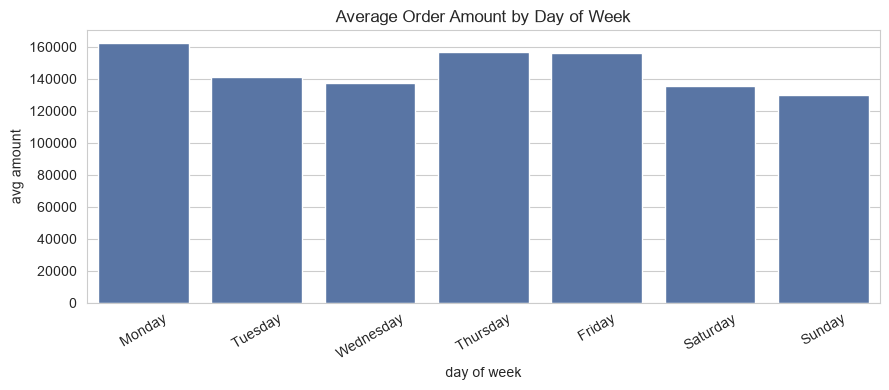

In [23]:
# [도식] 요일별 평균 매출 막대그래프 — 부품이 곧 인사이트가 된다
plt.figure(figsize=(9, 4))
sns.barplot(x=dow_sales.index, y=dow_sales.values, color="#4C72B0")
plt.title("Average Order Amount by Day of Week")
plt.xlabel("day of week"); plt.ylabel("avg amount")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

In [24]:
# 스스로 해보자! (5)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 시간대별 주문 건수
print(valid["hour"].value_counts().sort_index())              # value_counts

# 2) 주말 주문 비율
weekend = valid[valid["dow_num"] >= 5]               # >= 5 (토=5, 일=6)
print("주말 주문 비율:", round(len(weekend) / len(valid) * 100, 1), "%")

hour
0      87
1      85
2      73
3      80
4      94
5     103
6      89
7      74
8      90
9      64
10     79
11     91
12     82
13     77
14     78
15     91
16    108
17     76
18     72
19     84
20     88
21     69
22     75
23     79
Name: count, dtype: int64
주말 주문 비율: 27.5 %


In [25]:
night = valid[(valid["hour"] >= 0) & (valid["hour"] <= 6)]
print("심야(0~6시) 주문 비중:", round(len(night) / len(valid) * 100, 1), "%")

심야(0~6시) 주문 비중: 30.7 %


In [26]:
# 예제: 일별 매출 합계 (resample 'D')
ts = valid.set_index("order_dt").sort_index()   # 날짜를 인덱스로 + 시간순 정렬

daily_sales = ts["amount"].resample("D").sum()   # 하루 단위 합계
print("일별 매출 (앞 7일):")
print(daily_sales.head(7))
print("\n총 일수:", len(daily_sales))

일별 매출 (앞 7일):
order_dt
2025-01-01    2364000
2025-01-02    3206000
2025-01-03    2079000
2025-01-04    2810000
2025-01-05    2468000
2025-01-06    2994000
2025-01-07    3373000
Freq: D, Name: amount, dtype: int64

총 일수: 90


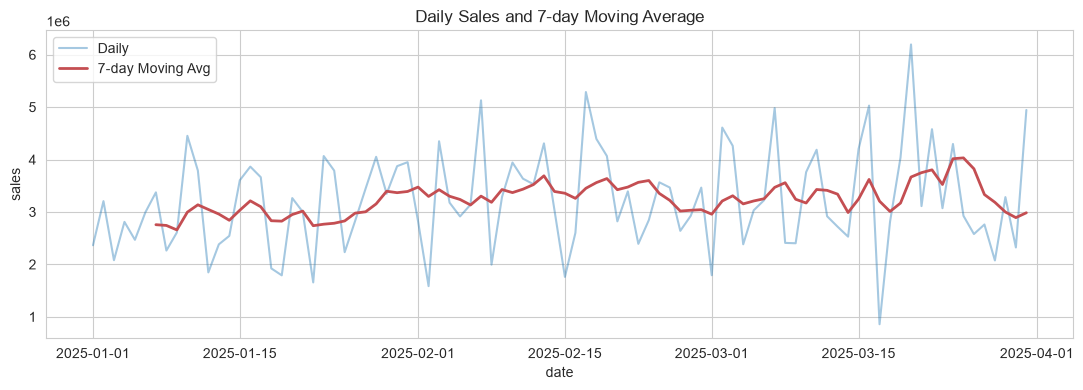

In [27]:
# 예제: 이동평균(rolling) — 들쭉날쭉한 일 매출을 7일 평균으로 부드럽게
daily_ma7 = daily_sales.rolling(7).mean()        # 최근 7일 이동평균

plt.figure(figsize=(11, 4))
plt.plot(daily_sales.index, daily_sales.values, alpha=0.4, label="Daily")
plt.plot(daily_ma7.index, daily_ma7.values, color="#C44E52", linewidth=2, label="7-day Moving Avg")
plt.title("Daily Sales and 7-day Moving Average")
plt.xlabel("date"); plt.ylabel("sales")
plt.legend()
plt.tight_layout(); plt.show()

In [28]:
# 예제: 주 단위로 자를 바꿔보기 (resample 'W')
weekly_sales = ts["amount"].resample("W").sum()
print("[주별 매출]")
print(weekly_sales)

[주별 매출]
order_dt
2025-01-05    12927000
2025-01-12    21327000
2025-01-19    19767000
2025-01-26    20837000
2025-02-02    23068000
2025-02-09    23986000
2025-02-16    22812000
2025-02-23    25194000
2025-03-02    22460000
2025-03-09    22691000
2025-03-16    25338000
2025-03-23    24663000
2025-03-30    20239000
2025-04-06     4945000
Freq: W-SUN, Name: amount, dtype: int64


order_dt
2025-01-01 00:00:00    2
2025-01-01 01:00:00    0
2025-01-01 02:00:00    1
2025-01-01 03:00:00    0
2025-01-01 04:00:00    2
2025-01-01 05:00:00    1
2025-01-01 06:00:00    1
2025-01-01 07:00:00    3
2025-01-01 08:00:00    0
2025-01-01 09:00:00    0
2025-01-01 10:00:00    0
2025-01-01 11:00:00    2
2025-01-01 12:00:00    0
2025-01-01 13:00:00    0
2025-01-01 14:00:00    1
2025-01-01 15:00:00    1
2025-01-01 16:00:00    1
2025-01-01 17:00:00    0
2025-01-01 18:00:00    0
2025-01-01 19:00:00    0
2025-01-01 20:00:00    2
2025-01-01 21:00:00    1
2025-01-01 22:00:00    1
2025-01-01 23:00:00    1
Freq: h, Name: amount, dtype: int64
              daily           ma3           ma7
order_dt                                       
2025-01-01  2364000           NaN           NaN
2025-01-02  3206000           NaN           NaN
2025-01-03  2079000  2.549667e+06           NaN
2025-01-04  2810000  2.698333e+06           NaN
2025-01-05  2468000  2.452333e+06           NaN
2025-01-06  2994000

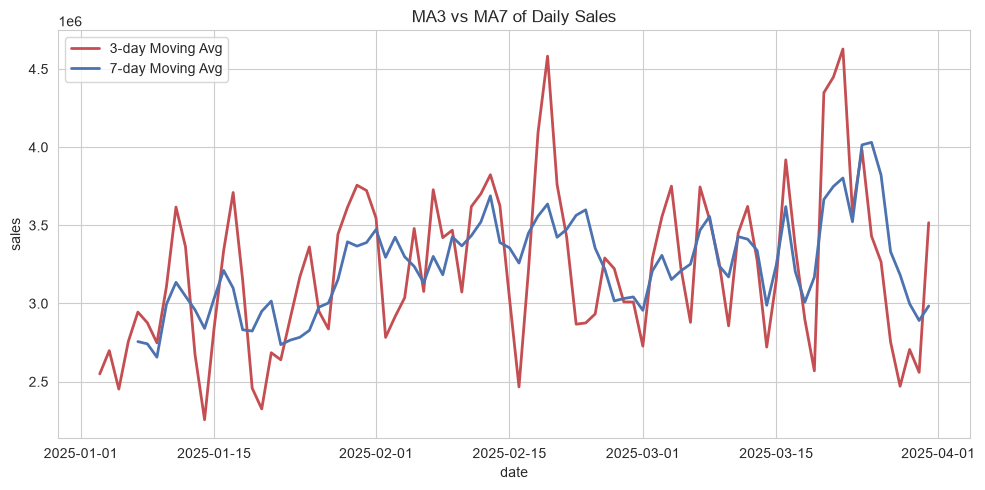

In [29]:
# 스스로 해보자! (6)
# 아래 주석(#)을 지우고 빈칸(___)을 채워보세요.

# 1) 시간대별 주문 건수
hourly = ts["amount"].resample("h").count()    # 힌트: "h"
print(hourly.head(24))

# 2) 3일 이동평균 vs 7일 이동평균
ma3 = daily_sales.rolling(3).mean()            # 힌트: 3
print(pd.DataFrame({"daily": daily_sales, "ma3": ma3, "ma7": daily_ma7}).head(10))
plt.plot(ma3.index, ma3.values, color="#C44E52", linewidth=2, label="3-day Moving Avg")
plt.plot(daily_ma7.index, daily_ma7.values, color="#4C72B0", linewidth=2, label="7-day Moving Avg")
plt.title("MA3 vs MA7 of Daily Sales")
plt.xlabel("date"); plt.ylabel("sales")
plt.legend()
plt.tight_layout(); plt.show()

In [33]:
# 1) 월별 주문 건수
monthly = ts["amount"].resample("ME").count()    # 힌트: "m"
print(monthly.head(12))

# 2) 3일 이동평균 vs 7일 이동평균
ma3 = daily_sales.rolling(3).mean()            # 힌트: 3
print(pd.DataFrame({"daily": daily_sales, "ma3": ma3, "ma7": daily_ma7}).head(10))

order_dt
2025-01-31    641
2025-02-28    643
2025-03-31    704
Freq: ME, Name: amount, dtype: int64
              daily           ma3           ma7
order_dt                                       
2025-01-01  2364000           NaN           NaN
2025-01-02  3206000           NaN           NaN
2025-01-03  2079000  2.549667e+06           NaN
2025-01-04  2810000  2.698333e+06           NaN
2025-01-05  2468000  2.452333e+06           NaN
2025-01-06  2994000  2.757333e+06           NaN
2025-01-07  3373000  2.945000e+06  2.756286e+06
2025-01-08  2263000  2.876667e+06  2.741857e+06
2025-01-09  2609000  2.748333e+06  2.656571e+06
2025-01-10  4452000  3.108000e+06  2.995571e+06


In [34]:
# 웹 서버 접속 로그 생성 (가상) — 한 줄이 통째로 문자열
np.random.seed(7)
n_logs = 1500
ips = [f"203.0.113.{k}" for k in range(1, 60)] + [f"198.51.100.{k}" for k in range(1, 60)]
paths = ["/", "/products", "/products/123", "/products/456", "/cart",
         "/checkout", "/login", "/search", "/api/orders"]
methods = ["GET", "GET", "GET", "POST"]
statuses = [200, 200, 200, 200, 200, 404, 500, 301]

# 시각: 7일치, 초 단위로 무작위 발생 후 정렬
log_times = pd.to_datetime("2025-03-01") + pd.to_timedelta(
    np.sort(np.random.randint(0, 7 * 24 * 3600, n_logs)), unit="s")

lines = []
for i in range(n_logs):
    ip = np.random.choice(ips)
    ts_str = log_times[i].strftime("%d/%b/%Y:%H:%M:%S")   # 12/Jan/2025:10:15:32
    m = np.random.choice(methods)
    p = np.random.choice(paths)
    st = np.random.choice(statuses)
    sz = np.random.randint(200, 5000)
    lines.append(f'{ip} - - [{ts_str}] "{m} {p} HTTP/1.1" {st} {sz}')

web_logs = pd.DataFrame({"raw": lines})
print("웹 로그 생성 완료:", web_logs.shape)
print("\n[원본 로그 한 줄은 이렇게 생겼습니다]")
for line in web_logs["raw"].head(3):
    print(line)

웹 로그 생성 완료: (1500, 1)

[원본 로그 한 줄은 이렇게 생겼습니다]
203.0.113.39 - - [01/Mar/2025:00:01:14] "GET / HTTP/1.1" 200 2371
198.51.100.21 - - [01/Mar/2025:00:02:24] "GET / HTTP/1.1" 301 284
198.51.100.17 - - [01/Mar/2025:00:02:28] "GET /search HTTP/1.1" 200 1448


In [35]:
# 시나리오 1 — 정규식으로 6개 필드를 한 번에 추출
pattern = (
    r"(?P<ip>\d+\.\d+\.\d+\.\d+)"        # IP: 숫자.숫자.숫자.숫자
    r" - - \["                            # 고정 구분 부분
    r"(?P<ts>[^\]]+)"                     # 시각: ] 가 아닌 글자들
    r"\] \""                              # ] 와 따옴표
    r"(?P<method>\w+) "                   # 방식: GET/POST
    r"(?P<path>\S+)"                      # 경로: 공백 아닌 글자들
    r"[^\"]*\" "                          # HTTP/1.1 부분 건너뛰기
    r"(?P<status>\d+) "                   # 상태 코드
    r"(?P<size>\d+)"                      # 응답 크기
)
logs = web_logs["raw"].str.extract(pattern)
print("추출된 표:", logs.shape)
print(logs.head())
print("\n추출 실패(어느 한 칸이라도 NaN) 행 수:", logs.isna().any(axis=1).sum())

추출된 표: (1500, 6)
              ip                    ts method       path status  size
0   203.0.113.39  01/Mar/2025:00:01:14    GET          /    200  2371
1  198.51.100.21  01/Mar/2025:00:02:24    GET          /    301   284
2  198.51.100.17  01/Mar/2025:00:02:28    GET    /search    200  1448
3   203.0.113.35  01/Mar/2025:00:03:56    GET      /cart    404  3921
4   203.0.113.47  01/Mar/2025:00:14:29    GET  /products    500  2580

추출 실패(어느 한 칸이라도 NaN) 행 수: 0


In [36]:
# 시나리오 2 — 타입 정리(날짜·숫자) + dt 부품
logs["ts"] = pd.to_datetime(logs["ts"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
logs["status"] = logs["status"].astype(int)
logs["size"] = logs["size"].astype(int)

# dt 부품: 시각(hour)과 요일
logs["hour"] = logs["ts"].dt.hour
logs["dow_name"] = logs["ts"].dt.day_name()

print("정리 후 자료형:")
print(logs.dtypes)
print()
print(logs[["ip", "ts", "method", "path", "status", "hour", "dow_name"]].head())

정리 후 자료형:
ip                     str
ts          datetime64[us]
method                 str
path                   str
status               int64
size                 int64
hour                 int32
dow_name               str
dtype: object

              ip                  ts method       path  status  hour  dow_name
0   203.0.113.39 2025-03-01 00:01:14    GET          /     200     0  Saturday
1  198.51.100.21 2025-03-01 00:02:24    GET          /     301     0  Saturday
2  198.51.100.17 2025-03-01 00:02:28    GET    /search     200     0  Saturday
3   203.0.113.35 2025-03-01 00:03:56    GET      /cart     404     0  Saturday
4   203.0.113.47 2025-03-01 00:14:29    GET  /products     500     0  Saturday


In [37]:
# 시나리오 2 — 상태 코드·인기 경로 빠르게 집계
print("[상태 코드 분포]")
print(logs["status"].value_counts())

error_rate = (logs["status"] >= 400).mean() * 100   # 4xx·5xx 비율
print(f"\n오류 응답(4xx·5xx) 비율: {error_rate:.1f}%")

print("\n[요청이 많은 경로 TOP 5]")
print(logs["path"].value_counts().head())

[상태 코드 분포]
status
200    964
301    188
404    178
500    170
Name: count, dtype: int64

오류 응답(4xx·5xx) 비율: 23.2%

[요청이 많은 경로 TOP 5]
path
/                184
/search          175
/cart            173
/products/456    171
/products        168
Name: count, dtype: int64


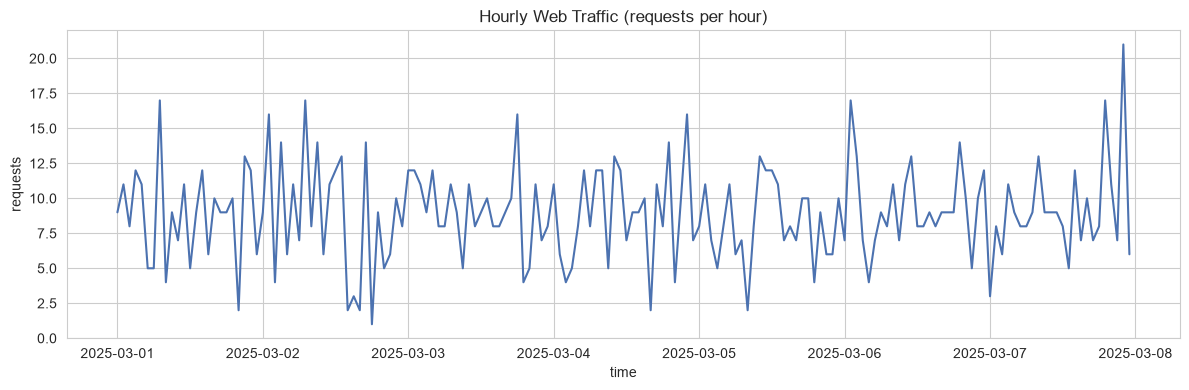

가장 트래픽이 많았던 시간대 TOP 3:
ts
2025-03-07 22:00:00    21
2025-03-01 07:00:00    17
2025-03-06 01:00:00    17
Name: ip, dtype: int64


In [38]:
# 시나리오 3 — 시간대별 트래픽 (resample 'h')
log_ts = logs.dropna(subset=["ts"]).set_index("ts").sort_index()
hourly_traffic = log_ts["ip"].resample("h").count()    # 시간당 요청 수

plt.figure(figsize=(12, 4))
plt.plot(hourly_traffic.index, hourly_traffic.values, color="#4C72B0")
plt.title("Hourly Web Traffic (requests per hour)")
plt.xlabel("time"); plt.ylabel("requests")
plt.tight_layout(); plt.show()

print("가장 트래픽이 많았던 시간대 TOP 3:")
print(hourly_traffic.sort_values(ascending=False).head(3))

=== 시간당(resample 'h') 트래픽 요약 ===
총 시간 슬롯 수: 168
평균: 8.93 | 최댓값: 21 | 최솟값: 1

=== 하루 중 시(0~23시)별 총 요청 수 (7일 합산) ===
hour
0     59
1     81
2     53
3     63
4     58
5     62
6     51
7     81
8     59
9     57
10    70
11    76
12    61
13    65
14    59
15    50
16    49
17    70
18    61
19    72
20    46
21    58
22    82
23    57
Name: count, dtype: int64

=== 요일별 총 요청 수 ===
dow_name
Monday       221
Tuesday      215
Wednesday    198
Thursday     225
Friday       221
Saturday     212
Sunday       208
Name: count, dtype: int64


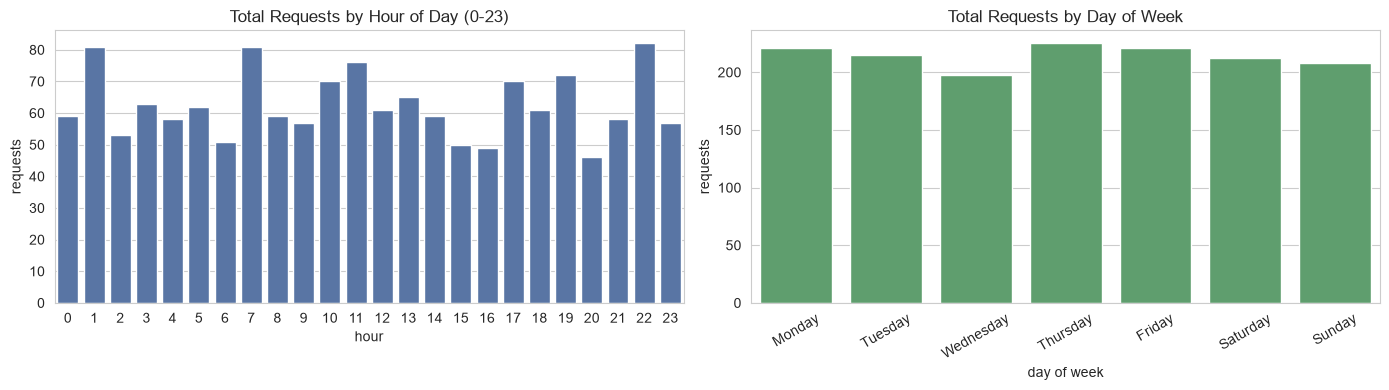

In [39]:
# 시간대별 트래픽 심화 — 시간당 요약 / 시(0~23시)별 합산 / 요일별 합산
print("=== 시간당(resample 'h') 트래픽 요약 ===")
print("총 시간 슬롯 수:", len(hourly_traffic))
print("평균:", round(hourly_traffic.mean(), 2), "| 최댓값:", hourly_traffic.max(), "| 최솟값:", hourly_traffic.min())

print("\n=== 하루 중 시(0~23시)별 총 요청 수 (7일 합산) ===")
by_hour = logs["hour"].value_counts().sort_index()
print(by_hour)

print("\n=== 요일별 총 요청 수 ===")
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = logs["dow_name"].value_counts().reindex(order_days)
print(by_dow)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=by_hour.index, y=by_hour.values, color="#4C72B0", ax=axes[0])
axes[0].set_title("Total Requests by Hour of Day (0-23)")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("requests")

sns.barplot(x=by_dow.index, y=by_dow.values, color="#55A868", ax=axes[1])
axes[1].set_title("Total Requests by Day of Week")
axes[1].set_xlabel("day of week"); axes[1].set_ylabel("requests")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

Q1=7.0, Q3=11.0, IQR=4.0
정상 범위: [1.0, 17.0]

이상치로 판정된 시간대 수: 1
ts
2025-03-07 22:00:00    21
Freq: h, Name: ip, dtype: int64

[제거 전] 평균: 8.93 | 최댓값: 21
[제거 후] 평균: 8.86 | 최댓값: 17 | 남은 시간 슬롯: 167/168


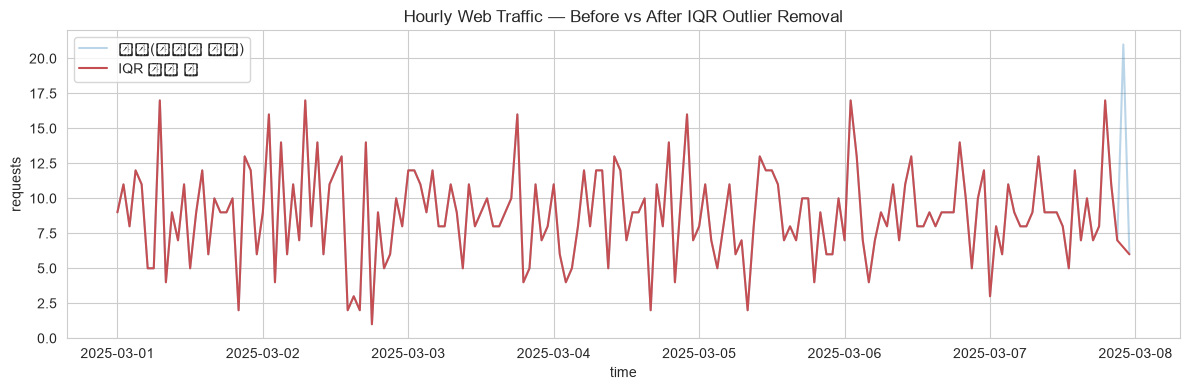

In [40]:
# IQR로 시간당 트래픽 이상치 제거 후 재확인
q1 = hourly_traffic.quantile(0.25)
q3 = hourly_traffic.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"정상 범위: [{lower}, {upper}]")

outliers = hourly_traffic[(hourly_traffic < lower) | (hourly_traffic > upper)]
print(f"\n이상치로 판정된 시간대 수: {len(outliers)}")
print(outliers.sort_values(ascending=False))

hourly_traffic_clean = hourly_traffic[(hourly_traffic >= lower) & (hourly_traffic <= upper)]
print(f"\n[제거 전] 평균: {hourly_traffic.mean():.2f} | 최댓값: {hourly_traffic.max()}")
print(f"[제거 후] 평균: {hourly_traffic_clean.mean():.2f} | 최댓값: {hourly_traffic_clean.max()} | 남은 시간 슬롯: {len(hourly_traffic_clean)}/{len(hourly_traffic)}")

plt.figure(figsize=(12, 4))
plt.plot(hourly_traffic.index, hourly_traffic.values, alpha=0.3, label="원본(이상치 포함)")
plt.plot(hourly_traffic_clean.index, hourly_traffic_clean.values, color="#C44E52", label="IQR 제거 후")
plt.title("Hourly Web Traffic — Before vs After IQR Outlier Removal")
plt.xlabel("time"); plt.ylabel("requests")
plt.legend()
plt.tight_layout(); plt.show()

[IP별 요청 수 상위 10건]
ip
198.51.100.41    24
203.0.113.58     21
198.51.100.52    19
203.0.113.27     19
203.0.113.18     19
203.0.113.35     18
198.51.100.24    18
198.51.100.28    18
203.0.113.56     18
203.0.113.16     18
Name: count, dtype: int64

평균: 12.71 | 표준편차: 3.31

Q1=10.25, Q3=15.0, IQR=4.75, 상한선=22.125

상한선(22.125) 초과 IP 수: 1
ip
198.51.100.41    24
Name: count, dtype: int64


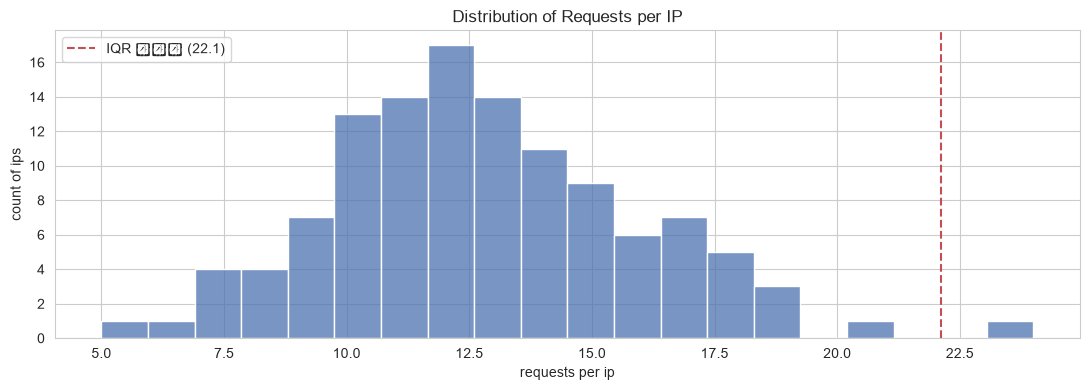

In [41]:
# 시나리오 4 — IP별 요청 수로 비정상(과다 요청) IP 탐지
ip_counts = logs["ip"].value_counts()

print("[IP별 요청 수 상위 10건]")
print(ip_counts.head(10))
print(f"\n평균: {ip_counts.mean():.2f} | 표준편차: {ip_counts.std():.2f}")

# IQR 기준으로 '비정상적으로 많이 요청한' IP를 찾는다
q1, q3 = ip_counts.quantile(0.25), ip_counts.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"\nQ1={q1}, Q3={q3}, IQR={iqr}, 상한선={upper}")

suspect_ips = ip_counts[ip_counts > upper]
print(f"\n상한선({upper}) 초과 IP 수: {len(suspect_ips)}")
print(suspect_ips)

plt.figure(figsize=(11, 4))
sns.histplot(ip_counts, bins=20, color="#4C72B0")
plt.axvline(upper, color="#C44E52", linestyle="--", label=f"IQR 상한선 ({upper:.1f})")
plt.title("Distribution of Requests per IP")
plt.xlabel("requests per ip"); plt.ylabel("count of ips")
plt.legend()
plt.tight_layout(); plt.show()

In [42]:
# 시나리오 4-1 — 상한선을 넘긴 IP(198.51.100.41)의 요청 내역을 통째로 뜯어본다
suspect_ip = suspect_ips.index[0]   # IQR 상한선을 넘긴 유일한 IP
target = logs[logs["ip"] == suspect_ip].sort_values("ts")

print(f"[{suspect_ip}] 전체 요청 {len(target)}건")
print(target[["ip", "ts", "method", "path", "status", "hour", "dow_name"]].to_string(index=False))

print("\n=== method 분포 ===")
print(target["method"].value_counts())

print("\n=== path 분포 ===")
print(target["path"].value_counts())

print("\n=== status 분포 ===")
print(target["status"].value_counts())

print("\n=== hour 분포 ===")
print(target["hour"].value_counts().sort_index())

print("\n=== dow_name 분포 ===")
print(target["dow_name"].value_counts())

[198.51.100.41] 전체 요청 24건
           ip                  ts method          path  status  hour  dow_name
198.51.100.41 2025-03-01 01:39:34    GET        /login     301     1  Saturday
198.51.100.41 2025-03-01 07:15:27   POST /products/456     500     7  Saturday
198.51.100.41 2025-03-01 16:43:35    GET /products/456     200    16  Saturday
198.51.100.41 2025-03-02 05:55:55    GET        /login     200     5    Sunday
198.51.100.41 2025-03-02 07:08:46    GET   /api/orders     200     7    Sunday
198.51.100.41 2025-03-02 07:52:12    GET     /checkout     200     7    Sunday
198.51.100.41 2025-03-02 09:05:07    GET     /products     500     9    Sunday
198.51.100.41 2025-03-02 17:53:03    GET     /checkout     301    17    Sunday
198.51.100.41 2025-03-02 22:08:51    GET     /checkout     301    22    Sunday
198.51.100.41 2025-03-03 02:30:36    GET     /products     200     2    Monday
198.51.100.41 2025-03-03 03:34:53    GET        /login     200     3    Monday
198.51.100.41 2025-03-03 2

[경로별 오류 건수]
path
/checkout        45
/                44
/cart            43
/products/456    43
/api/orders      40
/products        38
/login           35
/search          32
/products/123    28
Name: count, dtype: int64

[경로별 오류율(%) — 그 경로 전체 요청 대비]
path
/checkout        28.0
/products/456    25.1
/cart            24.9
/                23.9
/api/orders      23.8
/login           23.0
/products        22.6
/products/123    18.9
/search          18.3
Name: count, dtype: float64

오류율이 가장 높은 경로: /checkout
status
200    99
404    28
500    17
301    17
Name: count, dtype: int64


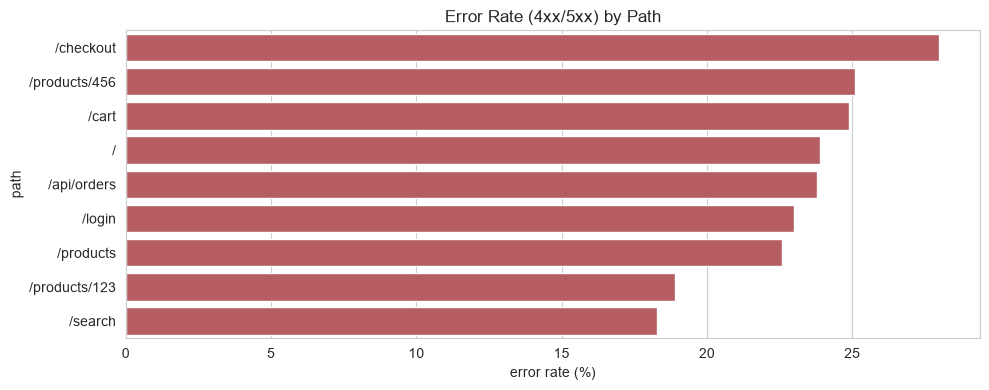

In [43]:
# 시나리오 5 — 경로(path)별 오류(4xx·5xx) 집계: 어디를 먼저 고쳐야 하나
errors = logs[logs["status"] >= 400]

err_by_path = errors["path"].value_counts()
total_by_path = logs["path"].value_counts()
error_rate_by_path = (err_by_path / total_by_path * 100).round(1).sort_values(ascending=False)

print("[경로별 오류 건수]")
print(err_by_path)
print("\n[경로별 오류율(%) — 그 경로 전체 요청 대비]")
print(error_rate_by_path)

top_path = error_rate_by_path.index[0]
print(f"\n오류율이 가장 높은 경로: {top_path}")
print(logs[logs["path"] == top_path]["status"].value_counts())

plt.figure(figsize=(10, 4))
sns.barplot(x=error_rate_by_path.values, y=error_rate_by_path.index, color="#C44E52")
plt.title("Error Rate (4xx/5xx) by Path")
plt.xlabel("error rate (%)"); plt.ylabel("path")
plt.tight_layout(); plt.show()

=== 시간대(hour)별 오류율 ===
      total  errors  error_rate
hour                           
0      59.0    13.0        22.0
1      81.0    15.0        18.5
2      53.0     9.0        17.0
3      63.0    14.0        22.2
4      58.0     9.0        15.5
5      62.0    17.0        27.4
6      51.0     8.0        15.7
7      81.0    21.0        25.9
8      59.0    15.0        25.4
9      57.0    12.0        21.1
10     70.0    16.0        22.9
11     76.0    15.0        19.7
12     61.0    18.0        29.5
13     65.0     8.0        12.3
14     59.0    19.0        32.2
15     50.0    16.0        32.0
16     49.0     9.0        18.4
17     70.0    21.0        30.0
18     61.0    19.0        31.1
19     72.0    14.0        19.4
20     46.0    14.0        30.4
21     58.0    12.0        20.7
22     82.0    22.0        26.8
23     57.0    12.0        21.1

=== 요일별 오류율 ===
           total  errors  error_rate
dow_name                            
Monday     221.0    53.0        24.0
Tuesday    215.0 

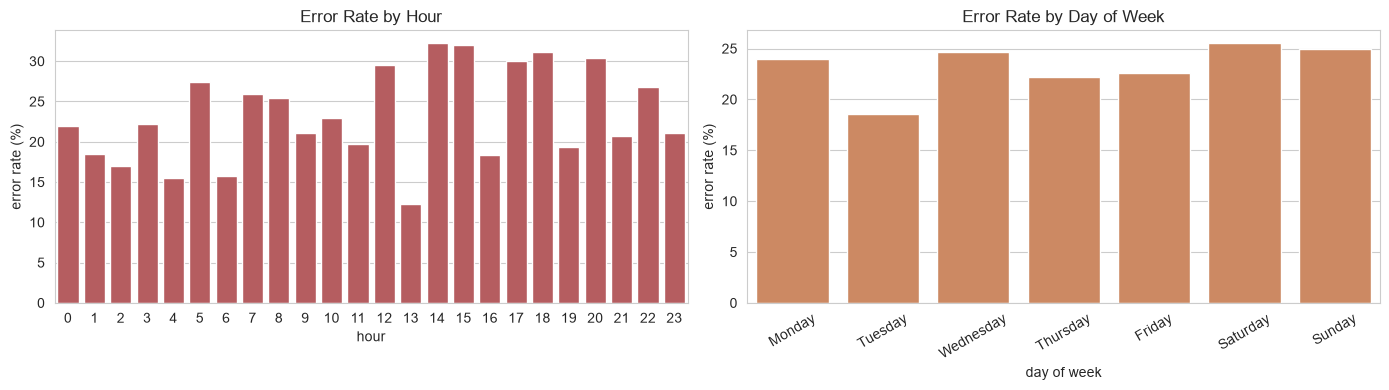

In [44]:
# 시나리오 6 — 오류율을 여러 축(시간대·요일·일자·method)으로 쪼개 비교
def error_summary(group):
    total = len(group)
    errors = int((group["status"] >= 400).sum())
    rate = round(errors / total * 100, 1) if total else 0.0
    return pd.Series({"total": total, "errors": errors, "error_rate": rate})

logs["date"] = logs["ts"].dt.date

print("=== 시간대(hour)별 오류율 ===")
by_hour_err = logs.groupby("hour").apply(error_summary, include_groups=False)
print(by_hour_err)

print()
print("=== 요일별 오류율 ===")
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow_err = logs.groupby("dow_name").apply(error_summary, include_groups=False).reindex(order_days)
print(by_dow_err)

print()
print("=== 일별 오류율 ===")
by_date_err = logs.groupby("date").apply(error_summary, include_groups=False)
print(by_date_err)

print()
print("=== method별 오류율 ===")
by_method_err = logs.groupby("method").apply(error_summary, include_groups=False)
print(by_method_err)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=by_hour_err.index, y=by_hour_err["error_rate"], color="#C44E52", ax=axes[0])
axes[0].set_title("Error Rate by Hour")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("error rate (%)")

sns.barplot(x=by_dow_err.index, y=by_dow_err["error_rate"], color="#DD8452", ax=axes[1])
axes[1].set_title("Error Rate by Day of Week")
axes[1].set_xlabel("day of week"); axes[1].set_ylabel("error rate (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

In [45]:
# 시나리오 7 — IP별 오류율(요청 5건 이상) + 응답 크기(size) 구간별 오류율
ip_err = logs.groupby("ip").apply(error_summary, include_groups=False)
ip_err_filtered = ip_err[ip_err["total"] >= 5].sort_values("error_rate", ascending=False)

print("=== IP별 오류율 TOP 10 (요청 5건 이상인 IP만) ===")
print(ip_err_filtered.head(10))
print()
print(f"요청 5건 이상 IP 수: {len(ip_err_filtered)}")

logs["size_bin"] = pd.cut(logs["size"], bins=[0, 1000, 2000, 3000, 4000, 5000],
                           labels=["0-1000", "1000-2000", "2000-3000", "3000-4000", "4000-5000"])
size_err = logs.groupby("size_bin", observed=True).apply(error_summary, include_groups=False)

print()
print("=== 응답 크기(size) 구간별 오류율 ===")
print(size_err)

print()
print("=== path x method 교차 오류율 TOP 10 ===")
cross_err = logs.groupby(["path", "method"]).apply(error_summary, include_groups=False)
print(cross_err.sort_values("error_rate", ascending=False).head(10))

=== IP별 오류율 TOP 10 (요청 5건 이상인 IP만) ===
               total  errors  error_rate
ip                                      
203.0.113.4      7.0     5.0        71.4
198.51.100.22   10.0     5.0        50.0
203.0.113.30    10.0     5.0        50.0
203.0.113.36    10.0     5.0        50.0
203.0.113.58    21.0    10.0        47.6
198.51.100.36    9.0     4.0        44.4
203.0.113.38     9.0     4.0        44.4
198.51.100.56   14.0     6.0        42.9
203.0.113.47    14.0     6.0        42.9
203.0.113.32    12.0     5.0        41.7

요청 5건 이상 IP 수: 118

=== 응답 크기(size) 구간별 오류율 ===
           total  errors  error_rate
size_bin                            
0-1000     252.0    60.0        23.8
1000-2000  334.0    70.0        21.0
2000-3000  313.0    69.0        22.0
3000-4000  306.0    80.0        26.1
4000-5000  295.0    69.0        23.4

=== path x method 교차 오류율 TOP 10 ===
                      total  errors  error_rate
path          method                           
/             POST     37.0 

# 웹 서버 접속 로그 분석 리포트

## 1. 데이터 개요
- 원본: `web_logs` — 1,500건의 access log 문자열(1컬럼), 2025-03-01 ~ 2025-03-07(7일치)
- 파싱 후: `logs` — 6개 필드(`ip`, `ts`, `method`, `path`, `status`, `size`) + 파생 컬럼(`hour`, `dow_name`)
- 정규식 추출 실패(어느 필드든 NaN) 0건 → 로그 포맷이 규칙적이라 1,500건 전량 파싱 성공

## 2. 필드 추출 및 정제
- `str.extract()` + named group 정규식으로 `IP - - [시각] "METHOD PATH HTTP/1.1" 상태코드 응답크기` 형식을 한 번에 분해
- `ts`는 `pd.to_datetime(format="%d/%b/%Y:%H:%M:%S", errors="coerce")`로 변환, `status`·`size`는 `astype(int)`로 정리
- `.dt.hour`, `.dt.day_name()`으로 시간대·요일 파생 컬럼 생성

## 3. 상태 코드 · 인기 경로
- 상태 코드 분포: 200(정상) 964건(64.3%) / 301(리다이렉트) 188건 / 404(Not Found) 178건 / 500(서버 오류) 170건
- **오류 응답(4xx·5xx) 비율: 23.2%** — 실서비스 기준으로는 높은 편에 속하는 수치
- 요청이 많은 경로 TOP 5: `/`(184) → `/search`(175) → `/cart`(173) → `/products/456`(171) → `/products`(168)
  - 특정 경로 쏠림 없이 대체로 고르게 분산

## 4. 시간대별 트래픽
- `set_index("ts")` + `resample("h")`로 시간당 요청 수 집계, 라인 차트로 시각화 (총 168개 시간 슬롯, 평균 8.93건/시간)
- 트래픽 최다 시간대 TOP 3: 2025-03-07 22시(21건) / 2025-03-01 07시(17건) / 2025-03-06 01시(17건)

**시(0~23시)별 총 요청 수 막대그래프**
- 1시·7시·22시가 80건대로 유독 높고, 20시(46건)·16시(50건)가 가장 낮음 — 최댓값(82, 22시)과 최솟값(46, 20시)의 차이가 약 1.8배로 시간대 간 들쭉날쭉한 편
- 다만 "심야는 낮고 낮에는 높다"는 식의 일관된 추세는 아니고, 높은 시간대(1시·7시·22시)와 낮은 시간대(16시·20시)가 뒤섞여 있어 실제 이용 패턴이라기보다 표본 변동(랜덤 노이즈)에 가까움

**요일별 총 요청 수 막대그래프**
- 목요일(225건)이 최다, 수요일(198건)이 최소로 요일 간 편차는 198~225 사이 → 최대/최소 차이 약 14%로 시간대별 편차보다 훨씬 완만
- 평일/주말 구분에 따른 뚜렷한 차이도 보이지 않음 (토·일 212·208건으로 평일과 비슷한 수준)

## 5. IQR 이상치 탐지 (시간당 트래픽)
- 시간당 트래픽(`hourly_traffic`) 기준 Q1=7, Q3=11, IQR=4 → 정상 범위 [1, 17]
- 이상치로 판정된 시간대는 **2025-03-07 22시(21건) 1건**뿐 — 위 막대그래프에서 22시가 가장 높게 나온 것과 일치
- 이상치 제거 후 평균은 8.93 → 8.86, 최댓값은 21 → 17로 소폭 하향 조정되었으나 전체 분포에 미치는 영향은 미미함 (168개 중 167개 유지)

## 6. IP별 요청 수 — 비정상적으로 많은 요청을 보낸 IP가 있는가
- 전체 118개 IP가 평균 12.71건, 표준편차 3.31건으로 요청. IQR 기준(Q1=10.25, Q3=15.0, IQR=4.75) 상한선은 **22.125건**
- 상한선을 넘긴 IP는 **`198.51.100.41` (24건) 단 1개** — TOP 10 나머지는 18~21건 사이로 완만하게 이어져 있어 이 IP만 분포에서 확실히 튀어나옴

**`198.51.100.41` 24건 전체 내역 분석**
- **method**: GET 20건 / POST 4건 — POST(주문·검색 등 액션) 비중이 낮고 GET 위주의 일반 브라우징 패턴. 봇/스크립트라면 보통 POST나 API 호출이 반복적으로 몰리는데 그런 정황이 없음
- **path**: `/checkout`(5) > `/login`(4) > `/products/456`·`/api/orders`·`/search`(각 3) 순으로 8개 경로에 고르게 분산 — 로그인 → 상품 조회 → 장바구니 → 체크아웃까지 이어지는 정상적인 쇼핑 동선과 일치. 동일 경로만 반복 요청하는 크롤링·스크래핑 특유의 패턴은 아님
- **status**: 200(정상) 15건(62.5%), 301 5건, 500 3건, 404 1건 — 오류 비율(8/24 ≈ 33%)이 전체 평균(23.2%)보다 다소 높지만, 표본이 24건뿐이라 우연히 튈 수 있는 범위
- **hour**: 1, 5, 7, 8, 9, 22시 등에 걸쳐 요청이 분산 — 짧은 시간에 몰아치는 버스트 요청이 없고, 7일 동안 하루 평균 3~4건씩 자연스럽게 흩어져 있음
- **dow_name**: 일요일 6건이 가장 많지만 화~금요일에도 고르게 나타남 — 특정 날짜에 집중된 패턴이 아님

- **판단**: 절대량(7일간 24건, 하루 평균 3.4건)이 적고, GET 위주·다양한 경로·시간 분산이라는 세 가지 특징 모두 크롤링 봇이나 무차별 요청(brute force)의 전형적 시그니처(동일 요청 반복, 초 단위 연타, 좁은 경로 집중)와 거리가 멀다. IQR상 유일한 이상치이긴 하나, 실제 행동 패턴은 로그인→쇼핑→체크아웃 흐름을 여러 날에 걸쳐 반복한 **활성 사용자**에 가까움. 따라서 "즉시 차단" 근거는 부족하고 **모니터링 대상으로만 표시**해 향후 요청량이 급증하는지 지켜보는 것이 합리적
- 결론적으로 이번 데이터에는 DDoS나 명백한 어뷰징으로 볼 만큼 비정상적인 IP는 없음 — 트래픽이 균등 난수로 생성된 가상 데이터라는 점과도 일치

## 7. 경로별 오류율 — 운영팀에 무엇을 제안할까
- 경로별 오류(4xx·5xx) 건수: `/checkout`(45) > `/`(44) > `/cart`(43) ≈ `/products/456`(43) > `/api/orders`(40) > `/products`(38) > `/login`(35) > `/search`(32) > `/products/123`(28)
- 단순 건수는 트래픽이 많은 경로가 유리하게(불리하게) 보일 수 있어, **오류율(%) = 오류 건수 / 그 경로 전체 요청 수**로 다시 정렬:
  - `/checkout` 28.0% > `/products/456` 25.1% > `/cart` 24.9% > `/` 23.9% > `/api/orders` 23.8% > `/login` 23.0% > `/products` 22.6% > `/products/123` 18.9% > `/search` 18.3%
- **오류율 1위는 `/checkout`(28.0%)** — 세부 상태코드를 보면 200 99건, 404 28건, 500 17건, 301 17건으로 **404가 500보다 많음**

**운영팀 제안**
1. `/checkout`을 최우선 점검 대상으로 지정한다 — 결제로 이어지는 핵심 전환 구간에서 오류율이 전체 평균(23.2%)보다도 높다는 것은 곧 매출 손실과 직결되는 문제이기 때문. 단순히 오류 건수가 아니라 **비즈니스 임팩트가 큰 경로**라는 점이 우선순위를 정하는 핵심 근거
2. `/checkout`의 오류 구성이 404 > 500 > 301 순이므로, "서버가 죽어서"보다는 **잘못된 요청 경로(끊긴 링크, 만료된 세션에서의 재접속, 유효하지 않은 상품 ID로의 결제 시도)** 가능성부터 확인하도록 제안 — 500이 원인이면 인프라/코드 결함, 404가 원인이면 프론트엔드 라우팅이나 세션 만료 처리 쪽을 봐야 하므로 대응 부서가 달라짐
3. `/products/456`(25.1%)처럼 특정 상품 상세 페이지만 오류율이 높다면, 해당 상품 데이터(재고 정보 등 연동 API)에 국한된 버그일 가능성이 있어 `/products`(22.6%, 목록 페이지)와 비교해 개별 상품 페이지 로직을 별도로 점검하도록 제안
4. `/search`(18.3%)가 상대적으로 가장 낮으므로, 오류의 원인이 "트래픽이 많아서"가 아니라 **경로별 로직 차이**에 있다는 근거로 활용 — 전체 평균 오류율만 보고 넘어가지 않고 경로 단위로 쪼개 봐야 하는 이유

## 8. 오류율 다차원 비교 — 시간대·요일·일자·method·IP·응답크기

전체 오류율(23.2%)과 경로별 오류율만으로는 "왜" 오류가 나는지 알기 어려워, 여러 축으로 쪼개 비교했다.

**시간대(hour)별 오류율**
- 최고 32.2%(14시) ~ 최저 12.3%(13시)로 편차가 큼 — 바로 옆 시간대(13시·14시)끼리도 20%p 가까이 벌어짐
- 15시(32.0%), 17시(30.0%), 18시(31.1%), 20시(30.4%)도 30% 안팎으로 높아 오후~저녁 시간대에 다소 몰리는 경향은 있으나, 4시(15.5%)·6시(15.7%)·13시(12.3%) 같은 낮은 시간대도 섞여 있어 뚜렷한 인과관계로 보기엔 표본(시간당 평균 62건)이 크지 않음

**요일별 오류율**
- 토요일(25.5%)·수요일(24.7%)·일요일(25.0%)이 상대적으로 높고, 화요일(18.6%)이 가장 낮음 — 최대-최소 차이 약 7%p로 시간대별 편차(약 20%p)보다는 작음

**일별 오류율**
- 3/1(25.5%)부터 3/7(22.6%)까지 18.6%~25.5% 범위 — 요일별 결과와 사실상 동일한 패턴(요일=날짜가 7일치라 1:1 대응)

**method별 오류율**
- GET 22.9% vs POST 24.2% — 거의 차이 없음. "쓰기(POST) 요청이라 더 많이 실패한다" 같은 가설은 이 데이터에서는 뒷받침되지 않음

**IP별 오류율 (요청 5건 이상)**
- `203.0.113.4`가 71.4%(7건 중 5건 오류)로 가장 높음 — 다만 표본이 7건뿐이라 통계적으로 불안정(5건 중 하나만 바뀌어도 오류율이 14%p씩 뛰는 규모)
- `198.51.100.22`·`203.0.113.30`·`203.0.113.36`도 50%(10건 중 5건)로 뒤를 이음 — 모두 요청 수 자체는 적어 "요청을 많이 보내서" 오류율이 높은 게 아니라, 적은 표본에서 우연히 오류가 몰렸을 가능성이 큼
- 앞서 IQR로 찾은 최다 요청 IP(`198.51.100.41`, 24건)의 오류율은 33.3%로 이 TOP 10에는 들지 않음 — 즉 "요청을 많이 한 IP"와 "오류를 많이 겪은 IP"는 서로 다른 IP

**응답 크기(size) 구간별 오류율**
- 3000~4000바이트 구간이 26.1%로 가장 높고, 1000~2000바이트 구간이 21.0%로 가장 낮음 — 구간 간 차이가 5%p 내외로 크지 않아 응답 크기와 오류율 사이에 뚜렷한 관계는 보이지 않음

**path × method 교차 오류율**
- `/  POST` 40.5%로 전체 조합 중 최고, 그다음 `/cart POST` 31.1%, `/checkout GET` 28.6%
- 앞서 경로 단독 기준으로는 `/checkout`(28.0%)이 1위였지만, method까지 쪼개보면 실제로는 `/ POST`와 `/cart POST`가 더 심각 — 경로 하나만 보고 끝내면 놓칠 수 있는 조합

**교차 분석 시사점**
- 오류율에 가장 뚜렷한 편차를 만드는 축은 **시간대(hour)**와 **path×method 조합**이고, 요일·일자·method 단독·응답크기는 편차가 작아 우선순위가 낮음
- IP별 오류율은 표본 수가 작아(대부분 5~24건) 순위 자체를 그대로 신뢰하기보다는, 요청 수와 오류율을 함께 놓고 "충분히 많이 시도했는데도 계속 실패하는 IP"인지 먼저 걸러야 함
- `/checkout`을 여전히 최우선으로 보되, `/ POST`(루트에 대한 POST — 비정상적인 요청일 가능성)와 `/cart POST`도 함께 점검 대상에 추가하는 것이 합리적

## 9. 종합 정리
- 정규식 named group을 쓰면 비정형 로그 한 줄짜리 문자열도 정형 테이블로 완전히 구조화할 수 있음을 확인
- 시간대별·요일별 집계와 IQR 검정을 종합하면, 이번 트래픽은 뚜렷한 러시아워나 이상 급증(DDoS성 트래픽 등) 없이 대체로 고르게 분산된 정상 범주의 패턴
- IP 단위로도 유의미한 어뷰징 정황은 없었으나, IQR 상한을 넘긴 `198.51.100.41`은 모니터링 대상으로 남겨두는 것이 합리적
- 경로별 오류율 분석은 "전체 오류율 23.2%"라는 하나의 숫자보다 훨씬 실행 가능한 인사이트를 제공 — `/checkout`처럼 비즈니스 임팩트가 큰 경로에서 오류율도 높다면 그 경로를 최우선으로 좁혀서 원인(404 vs 500)까지 구분해 제안하는 것이 핵심

## 10. 결론 — 웹서버 관리자라면 어떻게 해야 할까
이 로그를 실제로 운영 중인 서버의 접속 기록이라고 가정하면, 관리자로서 우선순위는 트래픽 패턴이 아니라 **오류율, 특히 비즈니스 임팩트가 큰 경로의 오류율**에 있다.

1. **최우선 조치 — `/checkout` 오류율(28.0%) 원인 규명**
   - 404가 500보다 많다는 세부 근거로 볼 때, 서버 다운보다는 잘못된 요청(끊긴 링크·만료 세션·유효하지 않은 상품 ID)일 가능성이 높음 — 프론트엔드 라우팅과 세션 관리 로직부터 점검
   - 결제 퍼널의 오류는 곧바로 매출 손실로 이어지므로, 오류 건수 절대량이 아니라 오류율과 경로의 중요도를 함께 고려해 우선순위를 정해야 함

2. **500 오류(서버 내부 오류) 원인 규명**
   - 500이 170건(전체의 11.3%)이나 발생 — 트래픽이 몰려서가 아니라(피크 시간대와 무관하게 분산) 특정 코드 경로의 결함일 가능성이 높음
   - `logs[logs["status"]==500]["path"].value_counts()`로 어떤 경로에서 500이 집중되는지 확인 후 해당 엔드포인트의 애플리케이션 로그를 우선 점검

3. **404 원인 점검 — 깨진 링크/오탐 여부**
   - `/products/456`처럼 특정 상품 ID 경로에서 404가 몰린다면 상품 삭제 시 리다이렉트 처리가 안 되고 있다는 신호일 수 있음

4. **IP 어뷰징은 낮은 우선순위, 다만 모니터링은 유지**
   - `198.51.100.41`이 유일한 IQR 이상치(24건)지만, 상세 내역상 GET 위주·다양한 경로·시간 분산으로 정상 사용자에 가까워 즉각 차단할 근거는 부족 — 다만 관찰 대상으로 등록해 향후 요청량이 급격히 늘어나거나 좁은 경로에 집중되는지 추적
   - 향후 실제 봇/어뷰징을 걸러낼 때는 요청 수뿐 아니라 이번처럼 **method 비율(POST 쏠림), path 편중도, 시간 간격(버스트 여부)**을 함께 봐야 오탐을 줄일 수 있음

5. **트래픽 자체는 당장 스케일링 이슈가 아님**
   - 시간대·요일별 분산이 고르고 IQR 이상치도 22시 1건뿐이라 급증·DDoS 정황은 없음
   - 다만 이 `resample("h")` + IQR 파이프라인(시간당 트래픽, IP별 요청 수 모두)을 모니터링 대시보드에 그대로 이식해 임계값 알림을 걸어두면 향후 실제 이상 발생 시 조기 탐지에 활용 가능

**한 줄 요약**: 지금 당장 서버를 증설하거나 IP를 차단할 필요는 없어 보이지만(트래픽·IP 패턴은 안정적이고, 유일한 이상치 IP도 실제로는 정상 사용자로 보임), 결제 퍼널인 `/checkout`의 오류율 28%는 매출과 직결되므로 가장 먼저 원인(404 중심)을 규명해야 한다.


In [46]:
# 코드 퀴즈 — 모범 답안
# 1) 정제(strip+lower) → 2) @ 뒤 도메인 추출 → 3) 조건 집계
clean = customers["email"].str.strip().str.lower()
domain = clean.str.split("@").str[1]
gmail_count = (domain == "gmail.com").sum()

print("gmail.com 고객 수:", gmail_count)

gmail.com 고객 수: 39
